# setup

In [80]:
import pandas as pd
from collections import Counter, defaultdict
import csv
import json
from pathlib import Path
import random
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.datasets import fetch_rcv1
import seaborn as sns
sns.set_theme(style="darkgrid")
import numpy as np
import requests
import pickle
from tqdm import tqdm
import networkx as nx
import os
import subprocess
from sklearn.feature_extraction.text import CountVectorizer

## helpers

In [81]:
def load_samples(dataset):
    with open(f"resource/dataset/{dataset}/samples.pkl", "rb") as samples_file:
        return pickle.load(samples_file)

def get_scores(scores_path):

    scores = []
    with open(scores_path) as scores_file:
        for score in scores_file:
            scores.append(int(score))
    return pd.DataFrame(scores, columns=["cls"])

def get_texts(texts_path):
    texts = []
    with open(texts_path, "rb") as texts_file:
        for text in texts_file:
            text = text.decode('utf-8')
            #text.replace("\n", " ")
            text = text.replace("\n", " ").replace("\r", " ").strip()

            texts.append(text)
    return pd.DataFrame(texts, columns=["text"])

def get_splits(splits_path):
    with open(splits_path, "rb") as splits_file:
        return pickle.load(splits_file)

def get_samples (texts_path, scores_path):
    texts_df = get_texts(texts_path)
    scores_df = get_scores(scores_path)
    samples_df = texts_df.join(scores_df)
    samples_df["idx"] = samples_df.index
    samples_df["cls"] = pd.factorize(samples_df["cls"], sort=True)[0]
    return samples_df[["idx", "text", "cls"]]

def normalize_space(text):
    return " ".join(str(text).split())

def read_csv_records(path):
    with open(path, "r", encoding="utf-8-sig", newline="") as csv_file:
        reader = csv.DictReader(csv_file)
        records = []
        for row in reader:
            normalized_row = {
                normalize_space(key): ("" if value is None else value)
                for key, value in row.items()
                if key is not None
            }
            if not any(str(value).strip() for value in normalized_row.values()):
                continue
            records.append(normalized_row)

    if not records:
        raise RuntimeError(f"No records found in {path}")

    return records

def format_counter(counter):
    return {key: int(value) for key, value in counter.most_common()}

In [82]:
def download_dataset(dataset, dataset_dir, base_url="http://150.164.2.44/datasets/"):
    # Create the target directory if it doesn't exist
    os.makedirs(dataset_dir, exist_ok=True)

    # Wget command to recursively download files into the target directory
    cmd = [
        "wget", "-r", "-np", "-nH", "--cut-dirs=2",
        "-R", "index.html*", "-P", dataset_dir, f"{base_url}{dataset}/"
    ]

    try:
        subprocess.run(cmd, check=True)
        print(f"Dataset downloaded successfully to '{dataset_dir}'")
    except subprocess.CalledProcessError as e:
        print(f"Error downloading dataset: {e}")

def download_file(url, destination):
    destination.parent.mkdir(parents=True, exist_ok=True)
    with requests.get(url, stream=True) as response:
        response.raise_for_status()
        with open(destination, "wb") as output_file:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    output_file.write(chunk)

def download_wos_46985_raw_from_hf(dataset_dir, repo_id="FlavioSoriano/wos-46985-rag-fuse", revision="main", force_download=False):
    dataset_dir = Path(dataset_dir)
    dataset_dir.mkdir(parents=True, exist_ok=True)
    files_to_download = [
        ("raw/WOS46985/X.txt", dataset_dir / "X.txt"),
        ("raw/WOS46985/Y.txt", dataset_dir / "Y.txt"),
        ("raw/WOS46985/YL1.txt", dataset_dir / "YL1.txt"),
        ("raw/WOS46985/YL2.txt", dataset_dir / "YL2.txt"),
        ("raw/WOS46985/Meta-data/Data.csv", dataset_dir / "Meta-data" / "Data.csv")
    ]

    base_url = f"https://huggingface.co/datasets/{repo_id}/resolve/{revision}"
    downloaded_paths = []
    for remote_path, local_path in files_to_download:
        if local_path.exists() and not force_download:
            print(f"Skipping existing file: {local_path}")
            downloaded_paths.append(local_path)
            continue

        download_url = f"{base_url}/{remote_path}"
        print(f"Downloading {download_url} -> {local_path}")
        download_file(download_url, local_path)
        downloaded_paths.append(local_path)

    return downloaded_paths

### folds

In [83]:
def get_splits(splits_path):
    with open(splits_path, "rb") as splits_file:
        return pickle.load(splits_file)

In [84]:
def train_val_split(ids, split_indice=.9):
    random.shuffle(ids)
    return np.split(
        ids,
            [
            int(
                split_indice*len(ids)
                )
            ]
         )

def deterministic_train_val_split(ids, split_indice=.9, seed=72):
    rng = random.Random(seed)
    shuffled = list(ids)
    rng.shuffle(shuffled)
    boundary = int(split_indice * len(shuffled))
    return np.array(shuffled[:boundary]), np.array(shuffled[boundary:])

def k_fold_split(ids, n_splits=5, random_state=72, shuffle=True):
    folds=[]

    kf=KFold(n_splits=n_splits, random_state=random_state, shuffle=shuffle)
    for fold_idx, splits in enumerate(kf.split(ids)):

        train_ids, val_ids = train_val_split(splits[0].tolist())
        test_ids=splits[1].tolist()

        folds.append({
            "fold_idx": fold_idx,
            "splits": {
                "train": train_ids.tolist(),
                "val": val_ids.tolist(),
                "test": test_ids
                }
            })

    return folds

def sk_fold_split(ids, cls, n_splits=5, random_state=72, shuffle=True):
    folds=[]
    kf=StratifiedKFold(n_splits=n_splits, random_state=random_state, shuffle=shuffle)
    for fold_idx, splits in enumerate(kf.split(ids, cls)):

        train_ids, val_ids = train_val_split(splits[0].tolist())
        test_ids=splits[1].tolist()

        folds.append({
            "fold_idx": fold_idx,
            "splits": {
                "train": [ids[idx] for idx in train_ids], #ids[train_ids],
                "val": [ids[idx] for idx in val_ids], #ids[val_ids],
                "test": [ids[idx] for idx in test_ids] #ids[test_ids]
                }
            })

    return folds

def sk_fold_split_deterministic(ids, cls, n_splits=5, random_state=72, shuffle=True, split_indice=.9):
    folds=[]
    kf=StratifiedKFold(n_splits=n_splits, random_state=random_state, shuffle=shuffle)
    for fold_idx, splits in enumerate(kf.split(ids, cls)):
        train_val_ids = [ids[idx] for idx in splits[0].tolist()]
        train_ids, val_ids = deterministic_train_val_split(
            train_val_ids,
            split_indice=split_indice,
            seed=random_state + fold_idx
        )
        test_ids = [ids[idx] for idx in splits[1].tolist()]

        folds.append({
            "fold_idx": fold_idx,
            "splits": {
                "train": train_ids.tolist(),
                "val": val_ids.tolist(),
                "test": test_ids
                }
            })

    return folds

def show_folds(folds, samples_to_show=10):
    for fold in folds:
        splits = fold['splits']
        print(f"fold: {fold['fold_idx']} ")
        print(f"train({len(splits['train'])}): {splits['train'][:samples_to_show]} ")
        print(f"val({len(splits['val'])}): {splits['val'][:samples_to_show]} ")
        print(f"test({len(splits['test'])}): {splits['test'][:samples_to_show]} \n")

In [85]:
def csr_row_to_text(csr_matrix, row_idx, max_terms=256):
    """Converts one sparse row into a pseudo-text sequence of active term ids."""
    row = csr_matrix.getrow(row_idx)
    if row.nnz == 0:
        return ""
    active_terms = row.indices[:max_terms]
    return " ".join([f"w{term_id}" for term_id in active_terms])


def greedy_multilabel_fold_indices(labels_ids, n_labels, n_splits=10, random_state=72):
    """Approximate multilabel stratification by greedily balancing label counts across folds."""
    rng = np.random.default_rng(random_state)
    num_samples = len(labels_ids)
    sample_indices = np.arange(num_samples)
    rng.shuffle(sample_indices)

    label_totals = np.zeros(n_labels, dtype=np.int64)
    for sample_labels in labels_ids:
        if sample_labels:
            label_totals[np.array(sample_labels, dtype=np.int64)] += 1

    desired_per_fold = np.tile(label_totals / n_splits, (n_splits, 1))
    current_per_fold = np.zeros((n_splits, n_labels), dtype=np.int64)
    fold_sizes = np.zeros(n_splits, dtype=np.int64)
    expected_fold_size = num_samples / n_splits

    def rarity_score(sample_labels):
        if not sample_labels:
            return 0.0
        freqs = label_totals[np.array(sample_labels, dtype=np.int64)]
        return float(np.sum(1.0 / np.maximum(freqs, 1)))

    ordered_samples = sorted(
        sample_indices.tolist(),
        key=lambda idx: (
            -len(labels_ids[idx]),
            -rarity_score(labels_ids[idx]),
            idx
        )
    )

    fold_to_indices = [[] for _ in range(n_splits)]

    for sample_idx in ordered_samples:
        sample_labels = labels_ids[sample_idx]
        if sample_labels:
            labels_np = np.array(sample_labels, dtype=np.int64)
            deficit = (desired_per_fold[:, labels_np] - current_per_fold[:, labels_np]).sum(axis=1)
        else:
            deficit = np.zeros(n_splits, dtype=np.float64)

        size_penalty = np.maximum(0.0, fold_sizes - expected_fold_size)
        score = deficit - size_penalty
        tie_break = rng.normal(loc=0.0, scale=1e-8, size=n_splits)
        chosen_fold = int(np.argmax(score + tie_break))

        fold_to_indices[chosen_fold].append(sample_idx)
        fold_sizes[chosen_fold] += 1
        if sample_labels:
            current_per_fold[chosen_fold, labels_np] += 1

    return fold_to_indices


def ml_k_fold_split(ids, labels_ids, n_labels, n_splits=10, random_state=72, split_indice=0.9):
    fold_test_indices = greedy_multilabel_fold_indices(
        labels_ids=labels_ids,
        n_labels=n_labels,
        n_splits=n_splits,
        random_state=random_state
    )

    all_local_indices = set(range(len(ids)))
    folds = []

    for fold_idx, test_local_indices in enumerate(fold_test_indices):
        test_local_set = set(test_local_indices)
        train_val_local = list(all_local_indices - test_local_set)
        train_local, val_local = train_val_split(train_val_local, split_indice=split_indice)

        folds.append({
            "fold_idx": fold_idx,
            "splits": {
                "train": [ids[idx] for idx in train_local.tolist()],
                "val": [ids[idx] for idx in val_local.tolist()],
                "test": [ids[idx] for idx in test_local_indices]
            }
        })

    return folds

In [86]:
ids = [0, 1, 2, 3]
k_fold_split(ids,n_splits=2)

[{'fold_idx': 0, 'splits': {'train': [0], 'val': [2], 'test': [1, 3]}},
 {'fold_idx': 1, 'splits': {'train': [1], 'val': [3], 'test': [0, 2]}}]

In [87]:
def load_K_fold_split(splits_df):
    folds=[]
    for _, splits in splits_df.iterrows():
        folds.append({
            "fold_idx": splits["fold_id"],
            "splits": {
                "train": splits["train_idxs"],
                "val": splits["val_idxs"],
                "test": splits["test_idxs"]
                }
            })

    return folds

### checkpoint

In [88]:
def checkpoint_samples(samples_df, dataset_dir):
    samples_df = samples_df[["idx", "text_idx", "text", "labels_ids", "labels"]]
    with open(dataset_dir+"samples.pkl", "wb") as samples_file:
        pickle.dump(samples_df.to_dict(orient="records"), samples_file)

In [89]:
def checkpoint_folds(folds, dataset_dir):
    for fold in folds:
        fold_dir = f"{dataset_dir}fold_{fold['fold_idx']}/"
        Path(fold_dir).mkdir(parents=True, exist_ok=True)
        for split, split_ids in fold['splits'].items():
            with open(f"{fold_dir}{split}.pkl", "wb") as split_file:
                pickle.dump(split_ids,split_file)


In [90]:
def checkpoint_relevance_map(relevance_map, dataset_dir):
    with open(dataset_dir+"relevance_map.pkl", "wb") as relevance_map_file:
        pickle.dump(relevance_map, relevance_map_file)

In [91]:
def checkpoint_label_cls(label_cls, dataset_dir):
    with open(dataset_dir+"label_cls.pkl", "wb") as label_cls_file:
        pickle.dump(label_cls, label_cls_file)

In [92]:
def checkpoint_labels_propensities(labels_propensities, dataset_dir):
    with open(dataset_dir+"labels_propensities.pkl", "wb") as labels_propensities_file:
        pickle.dump(labels_propensities, labels_propensities_file)

In [93]:
def checkpoint_text_cls(text_cls, dataset_dir):
    with open(dataset_dir+"text_cls.pkl", "wb") as text_cls_file:
        pickle.dump(text_cls, text_cls_file)

In [94]:
def checkpoint_labels_map(labels_map, dataset_dir):
    with open(dataset_dir+"labels_map.pkl", "wb") as labels_map_file:
        pickle.dump(labels_map, labels_map_file)

### dist

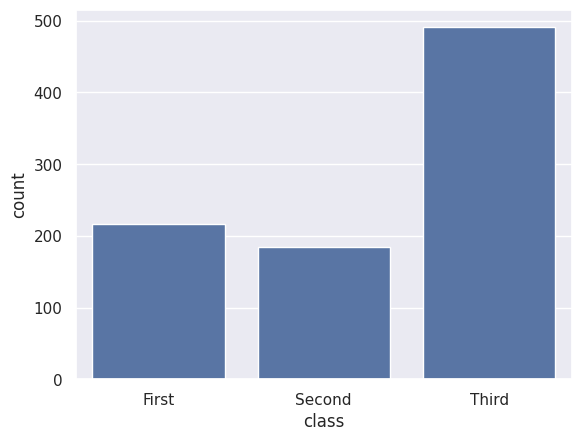

In [95]:
titanic = sns.load_dataset("titanic")
ax = sns.countplot(x="class", data=titanic)

In [96]:
def plot_label_distribution(samples_df, column):
    samples = []
    for idx, row in samples_df.iterrows():
        for label_idx in row[column]:
            samples.append(label_idx)
    return sns.countplot(samples)

### stats

In [97]:
def get_max_num_tokens(labels):
    max_num_tokens = 0
    for label in labels:
        num_tokens = len(label.split())
        if num_tokens > max_num_tokens:
            max_num_tokens = num_tokens
    return max_num_tokens

def len_stats (df):
    df = df.copy()
    df['text_len'] = df["text"].apply(lambda x: len(x.split()))
    text_len_summary = df['text_len'].quantile([.01, .5, .7, .8, .9, .95])
    display(pd.DataFrame(text_len_summary))

    df['label_len'] = df["labels"].apply(lambda labels: len(' '.join(labels).split()) )
    label_len_summary = df['label_len'].quantile([.5, .7, .8, .9, .95])
    display(pd.DataFrame(label_len_summary))

In [98]:
def inspect_stat(dataset):
    data_dir = f"resource/dataset/{dataset}/"
    with open(f"{data_dir}samples_with_keywords.pkl", "rb") as dataset_file:
        samples = pickle.load(dataset_file)
    samples_df = pd.DataFrame(samples)
    with open(f"{data_dir}label_cls.pkl", "rb") as f2:
        labels_cls = pickle.load(f2)

    t, h = [], [ ]
    for _, r in samples_df.iterrows():
        t_count, h_count = 0, 0
        for label_idx in r["labels_ids"]:
            if "tail" in labels_cls[label_idx]:
                t_count+=1
            if "head" in labels_cls[label_idx]:
                h_count+=1
        t.append(t_count)
        h.append(h_count)

## relevance

In [99]:
def get_relevance_map(df):
    relevance_map = {}
    qs1_ids = df["qs1_idx"].unique().tolist()
    qs1_ids.sort()
    qs2_ids = df["qs2_idx"].unique().tolist()
    qs2_ids.sort()

    for idx, row in df.iterrows():
        if row["cls"]==1:
            relevance_map.setdefault(row["qs1_idx"], [])
            relevance_map[row["qs1_idx"]].append(row["qs2_idx"])
    return relevance_map

## text and labels cls

In [100]:
def get_text_cls(label_ids, label_cls):
    cls = []
    for label_idx in label_ids:
        cls.extend(label_cls[label_idx])
    return list(set(cls))

# Main


## ACM

In [ ]:
dataset = "ACM"
dataset_raw_name = "acm"
labels_names = ["general literature", "hardware",
                "computer systems organization", "software", "data",
                "theory of computation", "mathematics of computing",
                "information systems", "computing methodologies",
                "computer applications", "computing milieux"]
len(labels_names)

In [ ]:
download_dataset(dataset_raw_name, dataset_dir=f"resource/dataset/raw_dataset/{dataset}/")

### samples

In [ ]:
samples_df = get_samples(
        texts_path=f"resource/dataset/raw_dataset/{dataset}/texts.txt",
        scores_path=f"resource/dataset/raw_dataset/{dataset}/score.txt"
    )
samples_df["labels"] = samples_df["cls"].apply(lambda x: [labels_names[x]])
samples_df["labels_ids"] = samples_df["cls"].apply(lambda x: [x])
samples_df["text_idx"] = samples_df["text"].astype('category').cat.codes
samples_df = samples_df[["idx", "text_idx", "text", "labels_ids", "labels"]]
samples_df

### labels cls

In [ ]:
labels_counter = Counter()
for labels_ids in samples_df['labels_ids']:
    labels_counter.update(labels_ids)


cutoff = round(0.2*len(labels_counter))


label_cls = {}
tail, head = [], []

for label_idx, freq in labels_counter.most_common():
    if len(head) <= cutoff:
        label_cls[label_idx]=["all","head"]
        head.append(label_idx)
    else:
        label_cls[label_idx]=["all", "tail"]
        tail.append(label_idx)

print(f"Num head labels: {len(head)}\n"
      f"Num tail labels: {len(tail)}\n"
      f"Total num labels: {len(head)+len(tail)}")

### text cls

In [ ]:
text_cls = {}
for _,row in samples_df.iterrows():
    text_idx = row["text_idx"]
    label_ids = row["labels_ids"]
    text_cls[text_idx] = get_text_cls(label_ids, label_cls)
len(text_cls)

### len stats

In [ ]:
len_stats(samples_df)

### folds

In [ ]:
splits_df = get_splits(
        splits_path=f"resource/dataset/raw_dataset/{dataset}/splits/split_10_with_val.pkl"
    )
splits_df

In [ ]:
samples_folds = load_K_fold_split(splits_df)
show_folds(samples_folds, samples_to_show=16)

### relevance map

In [ ]:
relevance_map = pd.Series(samples_df["labels_ids"].values, index=samples_df["text_idx"]).to_dict()
len(relevance_map)

### checkpoint

In [ ]:
print(f"Checkpointing {dataset} dataset")
dataset_dir=f"resource/dataset/{dataset}/"
Path(dataset_dir).mkdir(parents=True, exist_ok=True)
checkpoint_samples(samples_df, dataset_dir)
checkpoint_folds(samples_folds, dataset_dir)
checkpoint_relevance_map(relevance_map, dataset_dir)
checkpoint_label_cls(label_cls, dataset_dir)
checkpoint_text_cls(text_cls, dataset_dir)


## REUTERS

In [ ]:
dataset = "REUTERS"
dataset_raw_name = "reut90"
labels_names = ["rape-oil", "groundnut-oil", "dmk", "cpi", "meal-feed", "wpi",
                "livestock", "palm-oil", "jobs", "palladium", "nzdlr",
                "sunseed", "alum", "sorghum", "potato", "carcass", "money-fx",
                "grain", "coffee", "hog", "palmkernel", "rand", "zinc", "heat",
                "interest", "orange", "oilseed", "rice", "lumber", "rubber",
                "cotton", "crude", "fuel", "cocoa", "coconut", "nkr",
                "platinum", "coconut-oil", "instal-debt", "acq", "ship", "earn",
                "lei", "sugar", "dlr", "sun-meal", "naphtha", "lead",
                "pet-chem", "oat", "jet", "l-cattle", "trade", "castor-oil",
                "tea", "money-supply", "dfl", "retail", "income", "gas",
                "copper", "nickel", "barley", "corn", "rapeseed", "copra-cake",
                "propane", "veg-oil", "soy-meal", "tin", "groundnut", "wheat",
                "iron-steel", "reserves", "lin-oil", "silver", "gnp", "yen",
                "housing", "soy-oil", "sun-oil", "strategic-metal", "cpu",
                "nat-gas", "ipi", "gold", "rye", "soybean", "cotton-oil",
                "bop"]
len(labels_names)

In [ ]:
download_dataset(dataset_raw_name, dataset_dir=f"resource/dataset/raw_dataset/{dataset}/")

### samples

In [ ]:
samples_df = get_samples(
        texts_path=f"resource/dataset/raw_dataset/{dataset}/texts.txt",
        scores_path=f"resource/dataset/raw_dataset/{dataset}/score.txt"
    )
samples_df["labels"] = samples_df["cls"].apply(lambda x: [labels_names[x]])
samples_df["labels_ids"] = samples_df["cls"].apply(lambda x: [x])
samples_df["text_idx"] = samples_df["text"].astype('category').cat.codes
samples_df = samples_df[["idx", "text_idx", "text", "labels_ids", "labels"]]
samples_df

### labels cls

In [ ]:
labels_counter = Counter()
for labels_ids in samples_df['labels_ids']:
    labels_counter.update(labels_ids)


cutoff = round(0.2*len(labels_counter))


label_cls = {}
tail, head = [], []

for label_idx, freq in labels_counter.most_common():
    if len(head) <= cutoff:
        label_cls[label_idx]=["all","head"]
        head.append(label_idx)
    else:
        label_cls[label_idx]=["all", "tail"]
        tail.append(label_idx)

print(f"Num head labels: {len(head)}\n"
      f"Num tail labels: {len(tail)}\n"
      f"Total num labels: {len(head)+len(tail)}")

### text cls

In [ ]:
text_cls = {}
for _,row in samples_df.iterrows():
    text_idx = row["text_idx"]
    label_ids = row["labels_ids"]
    text_cls[text_idx] = get_text_cls(label_ids, label_cls)
len(text_cls)

### len stats

In [ ]:
len_stats(samples_df)

### folds

In [ ]:
splits_df = get_splits(
        splits_path=f"resource/dataset/raw_dataset/{dataset}/splits/split_10_with_val.pkl"
    )
splits_df

In [ ]:
samples_folds = load_K_fold_split(splits_df)
show_folds(samples_folds, samples_to_show=16)

### relevance map

In [ ]:
relevance_map = pd.Series(samples_df["labels_ids"].values, index=samples_df["text_idx"]).to_dict()
len(relevance_map)

### checkpoint

In [ ]:
print(f"Checkpointing {dataset} dataset")
dataset_dir=f"resource/dataset/{dataset}/"
Path(dataset_dir).mkdir(parents=True, exist_ok=True)
checkpoint_samples(samples_df, dataset_dir)
checkpoint_folds(samples_folds, dataset_dir)
checkpoint_relevance_map(relevance_map, dataset_dir)
checkpoint_label_cls(label_cls, dataset_dir)
checkpoint_text_cls(text_cls, dataset_dir)


## OHSUMED

In [ ]:
dataset = "OHSUMED"
dataset_raw_name = "ohsumed"
labels_names = ["Bacterial Infections and Mycoses", "Virus Diseases",
                "Parasitic Diseases", "Neoplasms", "Musculoskeletal Diseases",
                "Digestive System Diseases", "Stomatognathic Diseases",
                "Respiratory Tract Diseases", "Otorhinolaryngologic Diseases",
                "Nervous System Diseases", "Eye Diseases",
                "Urologic and Male Genital Diseases",
                "Female Genital Diseases and Pregnancy Complications",
                "Cardiovascular Diseases", "Hemic and Lymphatic Diseases",
                "Neonatal Diseases and Abnormalities",
                "Skin and Connective Tissue Diseases",
                "Nutritional and Metabolic Diseases", "Endocrine Diseases",
                "Immunologic Diseases", "Disorders of Environmental Origin",
                "Animal Diseases",
                "Pathological Conditions, Signs and Symptoms"]
len(labels_names)

In [ ]:
download_dataset(dataset_raw_name, dataset_dir=f"resource/dataset/raw_dataset/{dataset}/")

### samples

In [ ]:
samples_df = get_samples(
        texts_path=f"resource/dataset/raw_dataset/{dataset}/texts.txt",
        scores_path=f"resource/dataset/raw_dataset/{dataset}/score.txt"
    )
samples_df["labels"] = samples_df["cls"].apply(lambda x: [labels_names[x]])
samples_df["labels_ids"] = samples_df["cls"].apply(lambda x: [x])
samples_df["text_idx"] = samples_df["text"].astype('category').cat.codes
samples_df = samples_df[["idx", "text_idx", "text", "labels_ids", "labels"]]
samples_df

### labels cls

In [ ]:
labels_counter = Counter()
for labels_ids in samples_df['labels_ids']:
    labels_counter.update(labels_ids)


cutoff = round(0.2*len(labels_counter))


label_cls = {}
tail, head = [], []

for label_idx, freq in labels_counter.most_common():
    if len(head) <= cutoff:
        label_cls[label_idx]=["all","head"]
        head.append(label_idx)
    else:
        label_cls[label_idx]=["all", "tail"]
        tail.append(label_idx)

print(f"Num head labels: {len(head)}\n"
      f"Num tail labels: {len(tail)}\n"
      f"Total num labels: {len(head)+len(tail)}")

### text cls

In [ ]:
text_cls = {}
for _,row in samples_df.iterrows():
    text_idx = row["text_idx"]
    label_ids = row["labels_ids"]
    text_cls[text_idx] = get_text_cls(label_ids, label_cls)
len(text_cls)

### len stats

In [ ]:
len_stats(samples_df)

### folds

In [ ]:
splits_df = get_splits(
        splits_path=f"resource/dataset/raw_dataset/{dataset}/splits/split_10_with_val.pkl"
    )
splits_df

In [ ]:
samples_folds = load_K_fold_split(splits_df)
show_folds(samples_folds, samples_to_show=16)

### relevance map

In [ ]:
relevance_map = pd.Series(samples_df["labels_ids"].values, index=samples_df["text_idx"]).to_dict()
len(relevance_map)

### checkpoint

In [ ]:
print(f"Checkpointing {dataset} dataset")
dataset_dir=f"resource/dataset/{dataset}/"
Path(dataset_dir).mkdir(parents=True, exist_ok=True)
checkpoint_samples(samples_df, dataset_dir)
checkpoint_folds(samples_folds, dataset_dir)
checkpoint_relevance_map(relevance_map, dataset_dir)
checkpoint_label_cls(label_cls, dataset_dir)
checkpoint_text_cls(text_cls, dataset_dir)


## WOS (WOS-11967)

In [ ]:
dataset = "WOS"
dataset_raw_name = "wos11967"
labels_names = ["Computer vision", "Machine learning", "network security",
                "Cryptography", "Operating systems", "Electricity",
                "Electrical circuits", "Digital control", "Prejudice",
                "Social cognition", "Person perception",
                "Nonverbal communication", "Prosocial behavior",
                "computer-aided design", "Hydraulics",
                "Manufacturing engineering", "Machine design",
                "Fluid mechanics", "Ambient Intelligence", "Geotextile",
                "Remote Sensing", "Rainwater Harvesting", "Water Pollution",
                "Addiction", "Allergies", "Alzheimer's Disease",
                "Ankylosing Spondylitis", "Anxiety", "Molecular biology",
                "Cell biology", "Human Metabolism", "Immunology", "Genetics"]
len(labels_names)

In [ ]:
download_dataset(dataset_raw_name, dataset_dir=f"resource/dataset/raw_dataset/{dataset}/")

### samples

In [ ]:
samples_df = get_samples(
        texts_path=f"resource/dataset/raw_dataset/{dataset}/texts.txt",
        scores_path=f"resource/dataset/raw_dataset/{dataset}/score.txt"
    )
samples_df["labels"] = samples_df["cls"].apply(lambda x: [labels_names[x]])
samples_df["labels_ids"] = samples_df["cls"].apply(lambda x: [x])
samples_df["text_idx"] = samples_df["text"].astype('category').cat.codes
samples_df = samples_df[["idx", "text_idx", "text", "labels_ids", "labels"]]
samples_df

### labels cls

In [ ]:
labels_counter = Counter()
for labels_ids in samples_df['labels_ids']:
    labels_counter.update(labels_ids)


cutoff = round(0.2*len(labels_counter))


label_cls = {}
tail, head = [], []

for label_idx, freq in labels_counter.most_common():
    if len(head) <= cutoff:
        label_cls[label_idx]=["all","head"]
        head.append(label_idx)
    else:
        label_cls[label_idx]=["all", "tail"]
        tail.append(label_idx)

print(f"Num head labels: {len(head)}\n"
      f"Num tail labels: {len(tail)}\n"
      f"Total num labels: {len(head)+len(tail)}")

### text cls

In [ ]:
text_cls = {}
for _,row in samples_df.iterrows():
    text_idx = row["text_idx"]
    label_ids = row["labels_ids"]
    text_cls[text_idx] = get_text_cls(label_ids, label_cls)
len(text_cls)

### len stats

In [ ]:
len_stats(samples_df)

### folds

In [ ]:
splits_df = get_splits(
        splits_path=f"resource/dataset/raw_dataset/{dataset}/splits/split_10_with_val.pkl"
    )
splits_df

In [ ]:
samples_folds = load_K_fold_split(splits_df)
show_folds(samples_folds, samples_to_show=16)

### relevance map

In [ ]:
relevance_map = pd.Series(samples_df["labels_ids"].values, index=samples_df["text_idx"]).to_dict()
len(relevance_map)

### checkpoint

In [ ]:
print(f"Checkpointing {dataset} dataset")
dataset_dir=f"resource/dataset/{dataset}/"
Path(dataset_dir).mkdir(parents=True, exist_ok=True)
checkpoint_samples(samples_df, dataset_dir)
checkpoint_folds(samples_folds, dataset_dir)
checkpoint_relevance_map(relevance_map, dataset_dir)
checkpoint_label_cls(label_cls, dataset_dir)
checkpoint_text_cls(text_cls, dataset_dir)


## DBLP

In [ ]:
dataset = "DBLP"
dataset_raw_name = "dblp"
labels_names = ["computer vision", "computational linguistics",
                "biomedical engineering", "software engineering", "graphics",
                "data mining", "security and cryptography", "signal processing",
                "robotics", "theory"]
len(labels_names)

In [ ]:
download_dataset(dataset_raw_name, dataset_dir=f"resource/dataset/raw_dataset/{dataset}/")

### samples

In [ ]:
samples_df = get_samples(
        texts_path=f"resource/dataset/raw_dataset/{dataset}/texts.txt",
        scores_path=f"resource/dataset/raw_dataset/{dataset}/score.txt"
    )
samples_df["labels"] = samples_df["cls"].apply(lambda x: [labels_names[x]])
samples_df["labels_ids"] = samples_df["cls"].apply(lambda x: [x])
samples_df["text_idx"] = samples_df["text"].astype('category').cat.codes
samples_df = samples_df[["idx", "text_idx", "text", "labels_ids", "labels"]]
samples_df

### labels cls

In [ ]:
labels_counter = Counter()
for labels_ids in samples_df['labels_ids']:
    labels_counter.update(labels_ids)


cutoff = round(0.2*len(labels_counter))


label_cls = {}
tail, head = [], []

for label_idx, freq in labels_counter.most_common():
    if len(head) <= cutoff:
        label_cls[label_idx]=["all","head"]
        head.append(label_idx)
    else:
        label_cls[label_idx]=["all", "tail"]
        tail.append(label_idx)

print(f"Num head labels: {len(head)}\n"
      f"Num tail labels: {len(tail)}\n"
      f"Total num labels: {len(head)+len(tail)}")

### text cls

In [ ]:
text_cls = {}
for _,row in samples_df.iterrows():
    text_idx = row["text_idx"]
    label_ids = row["labels_ids"]
    text_cls[text_idx] = get_text_cls(label_ids, label_cls)
len(text_cls)

### len stats

In [ ]:
len_stats(samples_df)

### folds

In [ ]:
splits_df = get_splits(
        splits_path=f"resource/dataset/raw_dataset/{dataset}/splits/split_10_with_val.pkl"
    )
splits_df

In [ ]:
samples_folds = load_K_fold_split(splits_df)
show_folds(samples_folds, samples_to_show=16)

### relevance map

In [ ]:
relevance_map = pd.Series(samples_df["labels_ids"].values, index=samples_df["text_idx"]).to_dict()
len(relevance_map)

### checkpoint

In [ ]:
print(f"Checkpointing {dataset} dataset")
dataset_dir=f"resource/dataset/{dataset}/"
Path(dataset_dir).mkdir(parents=True, exist_ok=True)
checkpoint_samples(samples_df, dataset_dir)
checkpoint_folds(samples_folds, dataset_dir)
checkpoint_relevance_map(relevance_map, dataset_dir)
checkpoint_label_cls(label_cls, dataset_dir)
checkpoint_text_cls(text_cls, dataset_dir)

## 20NG

In [ ]:
dataset = "20NG"
dataset_raw_name = "20ng"
labels_names = ["atheist resources", "computer graphics",
                "computer os ms windows misc", "computer system ibm pc hardware",
                "computer system mac hardware", "computer windows x",
                "misc miscellaneous for sale", "rec autos", "rec motorcycles",
                "rec sport baseball", "rec sport hockey", "science crypt",
                "science electronics", "science med", "science space",
                "society religion christian", "talk politics guns",
                "talk politics mideast", "talk politics misc miscellaneous",
                "talk religion misc miscellaneous"]
len(labels_names)

In [ ]:
download_dataset(dataset_raw_name, dataset_dir=f"resource/dataset/raw_dataset/{dataset}/")

### samples

In [ ]:
samples_df = get_samples(
        texts_path=f"resource/dataset/raw_dataset/{dataset}/texts.txt",
        scores_path=f"resource/dataset/raw_dataset/{dataset}/score.txt"
    )
samples_df["labels"] = samples_df["cls"].apply(lambda x: [labels_names[x]])
samples_df["labels_ids"] = samples_df["cls"].apply(lambda x: [x])
samples_df["text_idx"] = samples_df["text"].astype('category').cat.codes
samples_df = samples_df[["idx", "text_idx", "text", "labels_ids", "labels"]]
samples_df

### labels cls

In [ ]:
labels_counter = Counter()
for labels_ids in samples_df['labels_ids']:
    labels_counter.update(labels_ids)


cutoff = round(0.2*len(labels_counter))


label_cls = {}
tail, head = [], []

for label_idx, freq in labels_counter.most_common():
    if len(head) <= cutoff:
        label_cls[label_idx]=["all","head"]
        head.append(label_idx)
    else:
        label_cls[label_idx]=["all", "tail"]
        tail.append(label_idx)

print(f"Num head labels: {len(head)}\n"
      f"Num tail labels: {len(tail)}\n"
      f"Total num labels: {len(head)+len(tail)}")

### text cls

In [ ]:
text_cls = {}
for _,row in samples_df.iterrows():
    text_idx = row["text_idx"]
    label_ids = row["labels_ids"]
    text_cls[text_idx] = get_text_cls(label_ids, label_cls)
len(text_cls)

### len stats

In [ ]:
len_stats(samples_df)

### folds

In [ ]:
splits_df = get_splits(
        splits_path=f"resource/dataset/raw_dataset/{dataset}/splits/split_10_with_val.pkl"
    )
splits_df

In [ ]:
samples_folds = load_K_fold_split(splits_df)
show_folds(samples_folds, samples_to_show=16)

### relevance map

In [ ]:
relevance_map = pd.Series(samples_df["labels_ids"].values, index=samples_df["text_idx"]).to_dict()
len(relevance_map)

### checkpoint

In [ ]:
print(f"Checkpointing {dataset} dataset")
dataset_dir=f"resource/dataset/{dataset}/"
Path(dataset_dir).mkdir(parents=True, exist_ok=True)
checkpoint_samples(samples_df, dataset_dir)
checkpoint_folds(samples_folds, dataset_dir)
checkpoint_relevance_map(relevance_map, dataset_dir)
checkpoint_label_cls(label_cls, dataset_dir)
checkpoint_text_cls(text_cls, dataset_dir)

## BOOKS

In [ ]:
dataset = "BOOKS"
dataset_raw_name = "books"
labels_names = ["children", "graphic comics", "paranormal fantasy",
                "history & biography", "crime & mystery thriller", "poetry",
                "romance", "young adult"]
len(labels_names)

In [ ]:
download_dataset(dataset_raw_name, dataset_dir=f"resource/dataset/raw_dataset/{dataset}/")

### samples

In [ ]:
samples_df = get_samples(
        texts_path=f"resource/dataset/raw_dataset/{dataset}/texts.txt",
        scores_path=f"resource/dataset/raw_dataset/{dataset}/score.txt"
    )
samples_df["labels"] = samples_df["cls"].apply(lambda x: [labels_names[x]])
samples_df["labels_ids"] = samples_df["cls"].apply(lambda x: [x])
samples_df["text_idx"] = samples_df["text"].astype('category').cat.codes
samples_df = samples_df[["idx", "text_idx", "text", "labels_ids", "labels"]]
samples_df

### labels cls

In [ ]:
labels_counter = Counter()
for labels_ids in samples_df['labels_ids']:
    labels_counter.update(labels_ids)


cutoff = round(0.2*len(labels_counter))


label_cls = {}
tail, head = [], []

for label_idx, freq in labels_counter.most_common():
    if len(head) <= cutoff:
        label_cls[label_idx]=["all","head"]
        head.append(label_idx)
    else:
        label_cls[label_idx]=["all", "tail"]
        tail.append(label_idx)

print(f"Num head labels: {len(head)}\n"
      f"Num tail labels: {len(tail)}\n"
      f"Total num labels: {len(head)+len(tail)}")

### text cls

In [ ]:
text_cls = {}
for _,row in samples_df.iterrows():
    text_idx = row["text_idx"]
    label_ids = row["labels_ids"]
    text_cls[text_idx] = get_text_cls(label_ids, label_cls)
len(text_cls)

### len stats

In [ ]:
len_stats(samples_df)

### folds

In [ ]:
splits_df = get_splits(
        splits_path=f"resource/dataset/raw_dataset/{dataset}/splits/split_10_with_val.pkl"
    )
splits_df

In [ ]:
samples_folds = load_K_fold_split(splits_df)
show_folds(samples_folds, samples_to_show=16)

### relevance map

In [ ]:
relevance_map = pd.Series(samples_df["labels_ids"].values, index=samples_df["text_idx"]).to_dict()
len(relevance_map)

### checkpoint

In [ ]:
print(f"Checkpointing {dataset} dataset")
dataset_dir=f"resource/dataset/{dataset}/"
Path(dataset_dir).mkdir(parents=True, exist_ok=True)
checkpoint_samples(samples_df, dataset_dir)
checkpoint_folds(samples_folds, dataset_dir)
checkpoint_relevance_map(relevance_map, dataset_dir)
checkpoint_label_cls(label_cls, dataset_dir)
checkpoint_text_cls(text_cls, dataset_dir)

## AGNEWS

In [ ]:
dataset = "AGNEWS"
dataset_raw_name = "agnews"
labels_names = ["world","sports","business","sci/tech"]
len(labels_names)

In [ ]:
download_dataset(dataset_raw_name, dataset_dir=f"resource/dataset/raw_dataset/{dataset}/")

### samples

In [ ]:
samples_df = get_samples(
        texts_path=f"resource/dataset/raw_dataset/{dataset}/texts.txt",
        scores_path=f"resource/dataset/raw_dataset/{dataset}/score.txt"
    )
samples_df["labels"] = samples_df["cls"].apply(lambda x: [labels_names[x]])
samples_df["labels_ids"] = samples_df["cls"].apply(lambda x: [x])
samples_df["text_idx"] = samples_df["text"].astype('category').cat.codes
samples_df = samples_df[["idx", "text_idx", "text", "labels_ids", "labels"]]
samples_df

### labels cls

In [ ]:
labels_counter = Counter()
for labels_ids in samples_df['labels_ids']:
    labels_counter.update(labels_ids)


cutoff = round(0.2*len(labels_counter))


label_cls = {}
tail, head = [], []

for label_idx, freq in labels_counter.most_common():
    if len(head) <= cutoff:
        label_cls[label_idx]=["all","head"]
        head.append(label_idx)
    else:
        label_cls[label_idx]=["all", "tail"]
        tail.append(label_idx)

print(f"Num head labels: {len(head)}\n"
      f"Num tail labels: {len(tail)}\n"
      f"Total num labels: {len(head)+len(tail)}")

### text cls

In [ ]:
text_cls = {}
for _,row in samples_df.iterrows():
    text_idx = row["text_idx"]
    label_ids = row["labels_ids"]
    text_cls[text_idx] = get_text_cls(label_ids, label_cls)
len(text_cls)

### len stats

In [ ]:
len_stats(samples_df)

### folds

In [ ]:
splits_df = get_splits(
        splits_path=f"resource/dataset/raw_dataset/{dataset}/splits/split_5_with_val.pkl"
    )
splits_df

In [ ]:
samples_folds = load_K_fold_split(splits_df)
show_folds(samples_folds, samples_to_show=16)

### relevance map

In [ ]:
relevance_map = pd.Series(samples_df["labels_ids"].values, index=samples_df["text_idx"]).to_dict()
len(relevance_map)

### checkpoint

In [ ]:
print(f"Checkpointing {dataset} dataset")
dataset_dir=f"resource/dataset/{dataset}/"
Path(dataset_dir).mkdir(parents=True, exist_ok=True)
checkpoint_samples(samples_df, dataset_dir)
checkpoint_folds(samples_folds, dataset_dir)
checkpoint_relevance_map(relevance_map, dataset_dir)
checkpoint_label_cls(label_cls, dataset_dir)
checkpoint_text_cls(text_cls, dataset_dir)


## SST2

In [ ]:
dataset = "SST2"
dataset_raw_name = "sst2"
labels_names = ["negative", "positive"]
len(labels_names)

In [ ]:
download_dataset(dataset_raw_name, dataset_dir=f"resource/dataset/raw_dataset/{dataset}/")

### samples

In [ ]:
samples_df = get_samples(
        texts_path=f"resource/dataset/raw_dataset/{dataset}/texts.txt",
        scores_path=f"resource/dataset/raw_dataset/{dataset}/score.txt"
    )
samples_df["labels"] = samples_df["cls"].apply(lambda x: [labels_names[x]])
samples_df["labels_ids"] = samples_df["cls"].apply(lambda x: [x])
samples_df["text_idx"] = samples_df["text"].astype('category').cat.codes
samples_df = samples_df[["idx", "text_idx", "text", "labels_ids", "labels"]]
samples_df

In [ ]:
print(len(samples_df), samples_df.shape[0], samples_df["text_idx"].nunique())

### labels cls

In [ ]:
labels_counter = Counter()
for labels_ids in samples_df['labels_ids']:
    labels_counter.update(labels_ids)


cutoff = round(0.2*len(labels_counter))


label_cls = {}
tail, head = [], []

for label_idx, freq in labels_counter.most_common():
    if len(head) <= cutoff:
        label_cls[label_idx]=["all","head"]
        head.append(label_idx)
    else:
        label_cls[label_idx]=["all", "tail"]
        tail.append(label_idx)

print(f"Num head labels: {len(head)}\n"
      f"Num tail labels: {len(tail)}\n"
      f"Total num labels: {len(head)+len(tail)}")

### text cls

In [ ]:
text_cls = {}
for _,row in samples_df.iterrows():
    text_idx = row["text_idx"]
    label_ids = row["labels_ids"]
    text_cls[text_idx] = get_text_cls(label_ids, label_cls)
len(text_cls)

### len stats

In [ ]:
len_stats(samples_df)

### folds

In [ ]:
splits_df = get_splits(
        splits_path=f"resource/dataset/raw_dataset/{dataset}/splits/split_10_with_val.pkl"
    )
splits_df

In [ ]:
samples_folds = load_K_fold_split(splits_df)
show_folds(samples_folds, samples_to_show=16)

### relevance map

In [ ]:
relevance_map = pd.Series(samples_df["labels_ids"].values, index=samples_df["text_idx"]).to_dict()
len(relevance_map)

### checkpoint

In [ ]:
print(f"Checkpointing {dataset} dataset")
dataset_dir=f"resource/dataset/{dataset}/"
Path(dataset_dir).mkdir(parents=True, exist_ok=True)
checkpoint_samples(samples_df, dataset_dir)
checkpoint_folds(samples_folds, dataset_dir)
checkpoint_relevance_map(relevance_map, dataset_dir)
checkpoint_label_cls(label_cls, dataset_dir)
checkpoint_text_cls(text_cls, dataset_dir)

## TREC
TREC-6 question classification dataset (6 coarse labels)

In [ ]:
dataset = "TREC"
dataset_raw_name = "trec"
labels_names = ["DESCRIPTION","ENTITY","ABBREVIATION","HUMAN","LOCATION","NUMERIC VALUE"]
len(labels_names)

In [ ]:
download_dataset(dataset_raw_name, dataset_dir=f"resource/dataset/raw_dataset/{dataset}/")

### samples

In [ ]:
samples_df = get_samples(
        texts_path=f"resource/dataset/raw_dataset/{dataset}/texts.txt",
        scores_path=f"resource/dataset/raw_dataset/{dataset}/score.txt"
    )
samples_df["labels"] = samples_df["cls"].apply(lambda x: [labels_names[x]])
samples_df["labels_ids"] = samples_df["cls"].apply(lambda x: [x])
samples_df["text_idx"] = samples_df["text"].astype('category').cat.codes
samples_df = samples_df[["idx", "text_idx", "text", "labels_ids", "labels"]]
samples_df

In [ ]:
print(len(samples_df), samples_df.shape[0], samples_df["text_idx"].nunique())

### labels cls

In [ ]:
labels_counter = Counter()
for labels_ids in samples_df['labels_ids']:
    labels_counter.update(labels_ids)

cutoff = round(0.2*len(labels_counter))

label_cls = {}
tail, head = [], []

for label_idx, freq in labels_counter.most_common():
    if len(head) <= cutoff:
        label_cls[label_idx]=["all","head"]
        head.append(label_idx)
    else:
        label_cls[label_idx]=["all", "tail"]
        tail.append(label_idx)

print(f"Num head labels: {len(head)}\n"
      f"Num tail labels: {len(tail)}\n"
      f"Total num labels: {len(head)+len(tail)}")

### text cls

In [ ]:
text_cls = {}
for _,row in samples_df.iterrows():
    text_idx = row["text_idx"]
    label_ids = row["labels_ids"]
    text_cls[text_idx] = get_text_cls(label_ids, label_cls)
len(text_cls)

### len stats

In [ ]:
len_stats(samples_df)

### folds

In [ ]:
splits_df = get_splits(
        splits_path=f"resource/dataset/raw_dataset/{dataset}/splits/split_10_with_val.pkl"
    )
splits_df

In [ ]:
samples_folds = load_K_fold_split(splits_df)
show_folds(samples_folds, samples_to_show=16)

### relevance map

In [ ]:
relevance_map = pd.Series(samples_df["labels_ids"].values, index=samples_df["text_idx"]).to_dict()
len(relevance_map)

### checkpoint

In [ ]:
print(f"Checkpointing {dataset} dataset")
dataset_dir=f"resource/dataset/{dataset}/"
Path(dataset_dir).mkdir(parents=True, exist_ok=True)
checkpoint_samples(samples_df, dataset_dir)
checkpoint_folds(samples_folds, dataset_dir)
checkpoint_relevance_map(relevance_map, dataset_dir)
checkpoint_label_cls(label_cls, dataset_dir)
checkpoint_text_cls(text_cls, dataset_dir)

## RCV1
RCV1-v1 from sklearn.datasets.fetch_rcv1 (multilabel)

In [ ]:
dataset = "RCV1"
dataset_raw_name = "rcv1-v2"

rcv1 = fetch_rcv1(subset="all", download_if_missing=True)
labels_names = rcv1.target_names.tolist()

print(f"Dataset: {dataset}")
print(f"Raw source: {dataset_raw_name}")
print(f"Num samples: {rcv1.data.shape[0]}")
print(f"Num labels: {len(labels_names)}")

In [ ]:
max_terms_per_text = 256
max_samples = None  # Keep as None for full RCV1-v2.


target_csr = rcv1.target.tocsr()
text_csr = rcv1.data.tocsr()

if max_samples is None:
    selected_indices = np.arange(text_csr.shape[0])
else:
    selected_indices = np.arange(min(max_samples, text_csr.shape[0]))

labels_ids = []
texts = []

for row_idx in tqdm(selected_indices, desc="Preparing RCV1 samples"):
    labels_ids.append(target_csr.getrow(row_idx).indices.tolist())
    texts.append(csr_row_to_text(text_csr, row_idx, max_terms=max_terms_per_text))

samples_df = pd.DataFrame({
    "idx": np.arange(len(selected_indices), dtype=np.int64),
    "text": texts,
    "labels_ids": labels_ids
})
samples_df["labels"] = samples_df["labels_ids"].apply(lambda row: [labels_names[label_idx] for label_idx in row])
samples_df["text_idx"] = samples_df["text"].astype("category").cat.codes
samples_df = samples_df[["idx", "text_idx", "text", "labels_ids", "labels"]]

print(samples_df.shape)
samples_df.head(3)

In [ ]:
labels_counter = Counter()
for sample_labels in samples_df["labels_ids"]:
    labels_counter.update(sample_labels)

cutoff = round(0.2 * len(labels_counter))

label_cls = {}
tail, head = [], []

for label_idx, freq in labels_counter.most_common():
    if len(head) <= cutoff:
        label_cls[label_idx] = ["all", "head"]
        head.append(label_idx)
    else:
        label_cls[label_idx] = ["all", "tail"]
        tail.append(label_idx)

print(f"Num head labels: {len(head)}")
print(f"Num tail labels: {len(tail)}")
print(f"Total num labels: {len(head) + len(tail)}")

In [ ]:
relevance_map = {}
for _, row in samples_df.iterrows():
    text_idx = int(row["text_idx"])
    relevance_map.setdefault(text_idx, set()).update(row["labels_ids"])

relevance_map = {text_idx: sorted(list(labels_set)) for text_idx, labels_set in relevance_map.items()}
print(len(relevance_map))

In [ ]:
samples_folds = ml_k_fold_split(
    ids=samples_df["idx"].tolist(),
    labels_ids=samples_df["labels_ids"].tolist(),
    n_labels=len(labels_names),
    n_splits=10,
    random_state=72,
    split_indice=0.9
)

show_folds(samples_folds, samples_to_show=16)

In [ ]:
text_cls = {}
for _, row in samples_df.iterrows():
    text_idx = int(row["text_idx"])
    text_cls.setdefault(text_idx, set())
    text_cls[text_idx].update(get_text_cls(row["labels_ids"], label_cls))

text_cls = {text_idx: sorted(list(classes)) for text_idx, classes in text_cls.items()}
print(f"Num text groups with classes: {len(text_cls)}")

In [ ]:
print(f"Checkpointing {dataset} dataset")
dataset_dir = f"resource/dataset/{dataset}/"
Path(dataset_dir).mkdir(parents=True, exist_ok=True)

checkpoint_samples(samples_df, dataset_dir)
checkpoint_folds(samples_folds, dataset_dir)
checkpoint_relevance_map(relevance_map, dataset_dir)
checkpoint_label_cls(label_cls, dataset_dir)
checkpoint_text_cls(text_cls, dataset_dir)

## WOS-46985
Official Web of Science variant from Mendeley Data (`10.17632/9rw3vkcfy4.2`).
In this section, `Y` remains the canonical 134-class flat target and the metadata CSV is used only to name labels via `Y -> area`.
`YL1` documents the 7 parent domains, while `YL2` is reused across parents and must not be treated as a globally unique flat label.

In [101]:
dataset = "WOS-46985"
dataset_raw_name = "wos-46985"
variant = "WOS46985"

source_page_url = "https://data.mendeley.com/datasets/9rw3vkcfy4/2"
source_doi = "10.17632/9rw3vkcfy4.2"
source_license = "CC BY 4.0"
hf_repo_id = "FlavioSoriano/wos-46985-rag-fuse"
hf_revision = "main"

expected_n_samples = 46985
expected_n_flat_labels = 134
expected_n_parent_labels = 7
expected_n_level2_codes = 53

raw_variant_dir = Path("resource/dataset/raw_dataset/WOS-46985")
required_paths = [
    raw_variant_dir / "X.txt",
    raw_variant_dir / "Y.txt",
    raw_variant_dir / "YL1.txt",
    raw_variant_dir / "YL2.txt",
    raw_variant_dir / "Meta-data" / "Data.csv"
]

downloaded_paths = download_wos_46985_raw_from_hf(
    dataset_dir=raw_variant_dir,
    repo_id=hf_repo_id,
    revision=hf_revision,
    force_download=True
)

assert raw_variant_dir.exists(), f"Directory not found: {raw_variant_dir}"
missing_paths = [str(path) for path in required_paths if not path.exists()]
assert len(missing_paths) == 0, f"Missing files in {raw_variant_dir}: {missing_paths}"

print(f"Dataset: {dataset}")
print(f"Raw source: {dataset_raw_name}")
print(f"Using raw source directory: {raw_variant_dir}")
print(f"Hugging Face raw repo: {hf_repo_id}@{hf_revision}")
print(f"Downloaded files: {len(downloaded_paths)}")
print(f"Source page: {source_page_url}")
print(f"DOI: {source_doi}")

Dataset: WOS-46985
Raw source: wos-46985
Using raw source directory: resource/dataset/raw_dataset/WOS-46985
Hugging Face raw repo: FlavioSoriano/wos-46985-rag-fuse@main
Downloaded files: 5
Source page: https://data.mendeley.com/datasets/9rw3vkcfy4/2
DOI: 10.17632/9rw3vkcfy4.2


### samples

In [ ]:
texts = get_texts(str(raw_variant_dir / "X.txt"))["text"].tolist()
y_values = [int(value) for value in get_texts(str(raw_variant_dir / "Y.txt"))["text"].tolist()]
yl1_values = [int(value) for value in get_texts(str(raw_variant_dir / "YL1.txt"))["text"].tolist()]
yl2_values = [int(value) for value in get_texts(str(raw_variant_dir / "YL2.txt"))["text"].tolist()]
metadata_records = read_csv_records(raw_variant_dir / "Meta-data" / "Data.csv")

n_x = len(texts)
n_y = len(y_values)
n_yl1 = len(yl1_values)
n_yl2 = len(yl2_values)
n_metadata = len(metadata_records)

assert n_x == n_y == n_yl1 == n_yl2 == n_metadata, (
    f"Line mismatch: X={n_x}, Y={n_y}, YL1={n_yl1}, YL2={n_yl2}, metadata={n_metadata}"
)
assert n_x == expected_n_samples, f"Expected {expected_n_samples} samples, got {n_x}"

n_y_unique = len(set(y_values))
n_yl1_unique = len(set(yl1_values))
n_yl2_unique = len(set(yl2_values))
n_parent_child_pairs = len(set(zip(yl1_values, yl2_values)))
n_label_triplets = len(set(zip(y_values, yl1_values, yl2_values)))

assert n_y_unique == expected_n_flat_labels, f"Expected {expected_n_flat_labels} flat labels in Y, got {n_y_unique}"
assert n_yl1_unique == expected_n_parent_labels, f"Expected {expected_n_parent_labels} parent labels in YL1, got {n_yl1_unique}"
assert n_yl2_unique == expected_n_level2_codes, f"Expected {expected_n_level2_codes} level-2 codes in YL2, got {n_yl2_unique}"

print(f"Unique labels in Y: {n_y_unique}")
print(f"Unique labels in YL1: {n_yl1_unique}")
print(f"Unique labels in YL2: {n_yl2_unique}")
print(f"Unique (YL1, YL2) pairs: {n_parent_child_pairs}")
print(f"Unique (Y, YL1, YL2) triplets: {n_label_triplets}")
print("YL2 is reused across parents and must not be used as the flat label id.")

by_y_area = defaultdict(Counter)
by_y_domain = defaultdict(Counter)
metadata_alignment_mismatches = 0
for idx, record in enumerate(metadata_records):
    area = normalize_space(record["area"])
    domain = normalize_space(record["Domain"])
    abstract = normalize_space(record["Abstract"])
    label_id = int(str(record["Y"]).strip())
    by_y_area[label_id][area] += 1
    by_y_domain[label_id][domain] += 1
    if abstract != normalize_space(texts[idx]):
        metadata_alignment_mismatches += 1

label_text_map = {
    label_id: area_counter.most_common(1)[0][0]
    for label_id, area_counter in by_y_area.items()
}
label_domain_map = {
    label_id: domain_counter.most_common(1)[0][0]
    for label_id, domain_counter in by_y_domain.items()
}
ambiguous_label_text_candidates = {
    str(label_id): format_counter(area_counter)
    for label_id, area_counter in by_y_area.items()
    if len(area_counter) > 1
}

assert len(label_text_map) == expected_n_flat_labels, (
    f"Expected {expected_n_flat_labels} label names, found {len(label_text_map)}"
)
assert len(set(label_text_map.values())) == expected_n_flat_labels, "Normalized label names are not globally unique"

labels_map = dict(sorted(label_text_map.items()))

samples = []
text_to_idx = {}
for idx, text in enumerate(texts):
    text_idx = text_to_idx.setdefault(text, len(text_to_idx))
    label_id = int(y_values[idx])
    samples.append({
        "idx": idx,
        "text_idx": text_idx,
        "text": text,
        "labels_ids": [label_id],
        "labels": [label_text_map[label_id]]
    })

samples_df = pd.DataFrame(samples)[["idx", "text_idx", "text", "labels_ids", "labels"]]
n_texts = samples_df["text_idx"].nunique()

print(f"Num documents: {n_x}")
print(f"Num unique texts: {n_texts}")
print(f"Labels named from metadata: {len(labels_map)}")
print(f"Metadata/text alignment mismatches: {metadata_alignment_mismatches}")
samples_df.head(10)

Unique labels in Y: 134
Unique labels in YL1: 7
Unique labels in YL2: 53
Unique (YL1, YL2) pairs: 133
Unique (Y, YL1, YL2) triplets: 137
YL2 is reused across parents and must not be used as the flat label id.
Num documents: 46985
Num unique texts: 46985
Labels named from metadata: 134
Metadata/text alignment mismatches: 0


,idx,text_idx,text,labels_ids,labels
0,0,0,(2 + 1)-dimensional non-linear optical waves t...,[12],[Symbolic computation]
1,1,1,(beta-amyloid (A beta) and tau pathology becom...,[74],[Alzheimer's Disease]
2,2,2,(D)ecreasing of energy consumption and environ...,[68],[Green Building]


### labels cls

In [103]:
labels_counter = Counter()
for labels_ids in samples_df['labels_ids']:
    labels_counter.update(labels_ids)

cutoff = round(0.2*len(labels_counter))

label_cls = {}
tail, head = [], []

for label_idx, freq in labels_counter.most_common():
    if len(head) <= cutoff:
        label_cls[label_idx]=["all","head"]
        head.append(label_idx)
    else:
        label_cls[label_idx]=["all", "tail"]
        tail.append(label_idx)

print(f"Num head labels: {len(head)}\n"
      f"Num tail labels: {len(tail)}\n"
      f"Total num labels: {len(head)+len(tail)}")

Num head labels: 28
Num tail labels: 106
Total num labels: 134


### text cls

In [104]:
text_cls = {}
for _,row in samples_df.iterrows():
    text_idx = row["text_idx"]
    label_ids = row["labels_ids"]
    text_cls[text_idx] = get_text_cls(label_ids, label_cls)
len(text_cls)

46985

### len stats

In [105]:
len_stats(samples_df)

,text_len
0.01,61.0
0.50,197.0
0.70,236.0
0.80,253.0
0.90,284.0
0.95,320.0


,label_len
0.50,2.0
0.70,2.0
0.80,2.0
0.90,2.0
0.95,3.0


### folds

In [106]:
samples_folds = sk_fold_split_deterministic(
    ids=samples_df["idx"].tolist(),
    cls=[label_ids[0] for label_ids in samples_df["labels_ids"]],
    n_splits=10,
    random_state=72,
    shuffle=True,
    split_indice=.9
)

show_folds(samples_folds, samples_to_show=16)

fold: 0 
train(38057): [5819, 4727, 23524, 5184, 19185, 32235, 44653, 35502, 176, 19791, 1991, 19394, 42711, 17493, 4320, 26265] 
val(4229): [41205, 39143, 11446, 38097, 29676, 32503, 25995, 35024, 6361, 15245, 13756, 22972, 4424, 22998, 43233, 17175] 
test(4699): [4, 40, 50, 54, 65, 69, 73, 101, 114, 136, 139, 143, 193, 236, 243, 266] 

fold: 1 
train(38057): [26575, 7704, 29968, 8196, 18364, 8402, 21187, 36743, 18970, 44186, 1524, 39601, 18218, 8640, 13568, 20526] 
val(4229): [6210, 29656, 40405, 1667, 24062, 9393, 35732, 25714, 387, 40367, 45139, 11378, 8166, 31727, 16862, 16002] 
test(4699): [9, 12, 21, 33, 38, 55, 56, 62, 77, 79, 80, 152, 156, 177, 182, 189] 

fold: 2 
train(38057): [27201, 2910, 34450, 14150, 10860, 38236, 27860, 22186, 3505, 24865, 22112, 27494, 20062, 1706, 22545, 5017] 
val(4229): [2779, 21908, 9026, 2452, 68, 16603, 40550, 32343, 40330, 18588, 38909, 11035, 11652, 37490, 33210, 31718] 
test(4699): [6, 11, 61, 83, 88, 92, 100, 110, 112, 115, 121, 134, 137, 141

### relevance map

In [107]:
relevance_map = pd.Series(samples_df["labels_ids"].values, index=samples_df["text_idx"]).to_dict()
len(relevance_map)

46985

### checkpoint

In [108]:
print(f"Checkpointing {dataset} dataset")
dataset_dir=f"resource/dataset/{dataset}/"
Path(dataset_dir).mkdir(parents=True, exist_ok=True)

checkpoint_samples(samples_df, dataset_dir)
checkpoint_folds(samples_folds, dataset_dir)
checkpoint_relevance_map(relevance_map, dataset_dir)
checkpoint_label_cls(label_cls, dataset_dir)
checkpoint_text_cls(text_cls, dataset_dir)
checkpoint_labels_map(labels_map, dataset_dir)

metadata = {
    "dataset_name": "WOS-46985",
    "variant": variant,
    "n_samples": int(n_x),
    "n_texts": int(n_texts),
    "n_leaf_labels": int(n_y_unique),
    "n_parent_labels": int(n_yl1_unique),
    "n_level2_codes": int(n_yl2_unique),
    "n_parent_child_pairs": int(n_parent_child_pairs),
    "n_label_triplets": int(n_label_triplets),
    "label_semantics": {
        "Y": "flat target label",
        "YL1": "parent label",
        "YL2": "level-2 code reused across parents; not a globally unique flat label by itself"
    },
    "source_files": {
        "X.txt": str(raw_variant_dir / "X.txt"),
        "Y.txt": str(raw_variant_dir / "Y.txt"),
        "YL1.txt": str(raw_variant_dir / "YL1.txt"),
        "YL2.txt": str(raw_variant_dir / "YL2.txt"),
        "Data.csv": str(raw_variant_dir / "Meta-data" / "Data.csv")
    },
    "source": {
        "canonical_page_url": source_page_url,
        "doi": source_doi,
        "license": source_license,
        "hf_raw_repo_id": hf_repo_id,
        "hf_raw_revision": hf_revision
    },
    "label_domain_map": {str(k): v for k, v in sorted(label_domain_map.items())},
    "label_text_map": {str(k): v for k, v in sorted(label_text_map.items())},
    "ambiguous_label_text_candidates": ambiguous_label_text_candidates,
    "metadata_alignment_mismatches": int(metadata_alignment_mismatches)
}

metadata_path = f"{dataset_dir}metadata.json"
with open(metadata_path, "w", encoding="utf-8") as metadata_file:
    json.dump(metadata, metadata_file, indent=2)

saved_paths = [
    f"{dataset_dir}samples.pkl",
    f"{dataset_dir}relevance_map.pkl",
    f"{dataset_dir}label_cls.pkl",
    f"{dataset_dir}text_cls.pkl",
    f"{dataset_dir}labels_map.pkl",
    metadata_path
]

print(f"Num documents: {n_x}")
print(f"Unique labels in Y: {n_y_unique}")
print(f"Unique labels in YL1: {n_yl1_unique}")
print(f"Unique labels in YL2: {n_yl2_unique}")
print("Saved files:")
for saved_path in saved_paths:
    print(saved_path)

Checkpointing WOS-46985 dataset
Num documents: 46985
Unique labels in Y: 134
Unique labels in YL1: 7
Unique labels in YL2: 53
Saved files:
resource/dataset/WOS-46985/samples.pkl
resource/dataset/WOS-46985/relevance_map.pkl
resource/dataset/WOS-46985/label_cls.pkl
resource/dataset/WOS-46985/text_cls.pkl
resource/dataset/WOS-46985/labels_map.pkl
resource/dataset/WOS-46985/metadata.json
